In [1]:
from quantum_part import *
from Bayesian_part import *
from strategy_optimization import *
import random

import qutip as qt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.stats import norm
import torch
import gpytorch
from gpytorch.kernels import RBFKernel, ScaleKernel, MaternKernel, PolynomialKernel
from gpytorch.means import ZeroMean, ConstantMean
from gpytorch.distributions import MultivariateNormal
from botorch.models.gpytorch import GPyTorchModel
from torch.distributions import Bernoulli, Normal

In [2]:
############################# Definition of useful constants ##############################
############################################################################################
# definition for all the basis and pauli matrix
paulis = {
    "X": qt.sigmax(),
    "Y": qt.sigmay(),
    "Z": qt.sigmaz()
}

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

pauli_eigen = {
    'Z': {+1: ket0, -1: ket1},
    'X': {+1: (ket0 + ket1).unit(),
          -1: (ket0 - ket1).unit()},
    'Y': {+1: (ket0 + 1j*ket1).unit(),
          -1: (ket0 - 1j*ket1).unit()}
}

############################################################################################
shadow_size = 300
qubit_num  = 2

In [4]:
# Define a quantum state plus
all_qubit = [(ket0+ket1).unit() for i in range(qubit_num)]
psi = qt.tensor(all_qubit)

# difine operator as \sigma_x \otimes \sigma_x \cdots for simplicity. estimations should be around 1
operator = qt.tensor(qt.sigmax(), qt.qeye(2))

rho = psi * psi.dag()
tlist = np.linspace(0, 2*np.pi, 1000)
####################################################################################
# definition of quantum dynamic
H = qt.tensor(qt.sigmaz(), qt.sigmaz())

# damping Hamiltonian model
gamma = 0.1
c_ops = [np.sqrt(gamma) * qt.tensor(qt.sigmaz(), qt.qeye(2))]

# result = qt.mesolve(H, psi, tlist, c_ops) # with damping
result = qt.mesolve(H, psi, tlist, []) # without damping

# expect = qt.expect(operator, result.states)

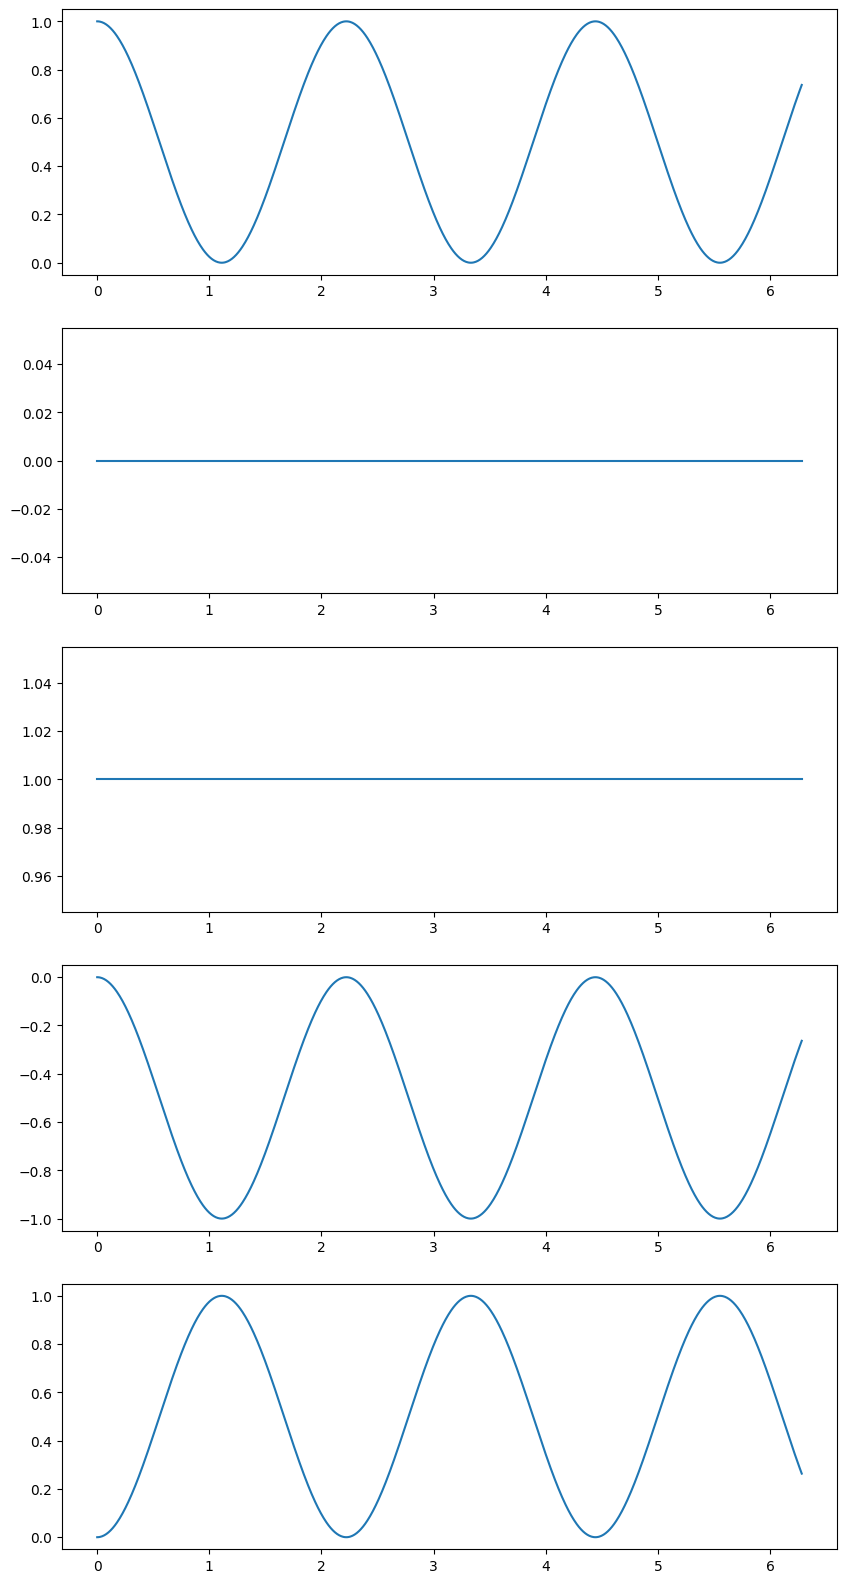

In [ ]:
# New dynamics
# dont run this if not testing the 2 qubit dynamics
# 1. Pure Ising
H = qt.tensor(qt.sigmaz(), qt.sigmaz())

# 2. Transverse-field Ising
H = (
    qt.tensor(qt.sigmaz(), qt.sigmaz())
    + 0.5 * (qt.tensor(qt.sigmax(), qt.qeye(2)) + qt.tensor(qt.qeye(2), qt.sigmax()))
)
result = qt.mesolve(H, psi, tlist, [])

operators = [
    qt.tensor(qt.sigmax(), qt.qeye(2)),
    qt.tensor(qt.sigmay(), qt.qeye(2)),
    qt.tensor(qt.sigmax(), qt.sigmax()),
    qt.tensor(qt.sigmay(), qt.sigmay()),
    qt.tensor(qt.sigmaz(), qt.sigmaz())
]

expect = [qt.expect(op, result.states) for op in operators]

fig, ax = plt.subplots(5,1, figsize=(10, 20))
for i in range(5):
    ax[i].plot(tlist, expect[i])
plt.show()
plt.close()

# Generation of data
This generate random outcome of pauli measurements at sparse time index. Datas are saved in measurement_df for further use.

In [5]:
indices = np.linspace(0, len(tlist) - 1, 200, dtype=int)
picked_times = tlist[indices]

# create variable name list for classical shadow
obs_list = []
for i in range(shadow_size):
    obs = create_random_pauli_obs(qubit_num)
    obs_list.append(obs)
records = []

for idx in indices:
    state_t = result.states[idx]
    rho = state_t if state_t.isoper else state_t * state_t.dag()
    # rho = result.states[idx] * result.states[idx].dag()
    time = tlist[idx]
    for shadow_id in range(shadow_size):
        obs = obs_list[shadow_id]
        measurements = pauli_measurement(rho, obs, qubit_num)

        for qubit, (pauli_label, outcome) in enumerate(measurements):
            records.append({
                # "time_idx": time_idx,
                "time": time,
                "shadow_id": shadow_id,
                "qubit": qubit,
                "pauli": pauli_label,
                "outcome": outcome,
            })

measurement_df = pd.DataFrame(records)

print(measurement_df)

            time  shadow_id  qubit pauli  outcome
0       0.000000          0      0     Z       -1
1       0.000000          0      1     Z        1
2       0.000000          1      0     Y        1
3       0.000000          1      1     Z        1
4       0.000000          2      0     Z       -1
...          ...        ...    ...   ...      ...
119995  6.283185        297      1     Z       -1
119996  6.283185        298      0     Z       -1
119997  6.283185        298      1     Y        1
119998  6.283185        299      0     X        1
119999  6.283185        299      1     Y        1

[120000 rows x 5 columns]


# Bayesian inference on shadow 
This part does Bayesian inference on separated shadow data. 

In [6]:
model_bank = train_conditional_gp_classifiers(
    measurement_df=measurement_df,
    qubit_num=qubit_num,
    shadow_ids=range(shadow_size),
)

shot_at_test_times = [[None for _ in range(shadow_size)] for _ in range(len(indices))]
for t_idx, idx in enumerate(indices):
    t_val = float(tlist[idx])
    for s_id in range(shadow_size):
        shot_at_test_times[t_idx][s_id] = simulate_classical_shadow_conditional(
            model_bank=model_bank,
            measurement_df=measurement_df,
            qubit_num=qubit_num,
            shadow_id=s_id,
            time_value=t_val,
        )


KeyboardInterrupt: 

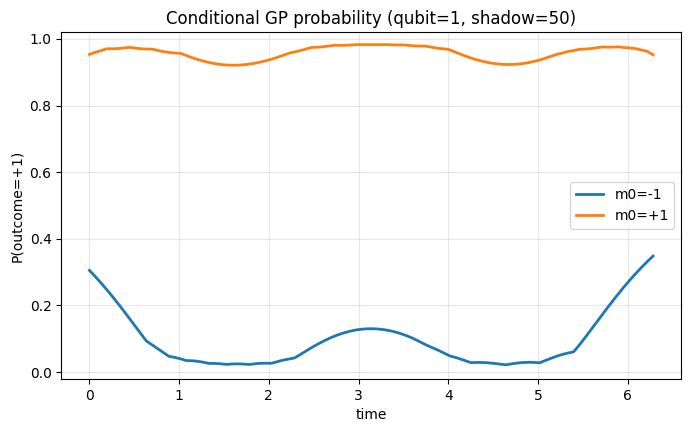

In [21]:
# Example: visualize qubit 1 (conditioned on qubit 0) for one shadow
fig, ax, curves = plot_conditional_probability_curves(
    model_bank=model_bank,
    qubit=1,
    shadow_id=50,
    t_values=tlist,
    measurement_df=measurement_df,   # lets function auto-pick observed conditioning patterns
)
plt.show()

In [15]:
from quantum_part import reconstruct_operator_dynamics_from_conditional_models

# choose reconstruction times (same as your picked indices)
recon_times = tlist #[indices]

results = reconstruct_operator_dynamics_from_conditional_models(
    model_bank=model_bank,
    measurement_df=measurement_df,
    qubit_num=qubit_num,
    operator=operator,
    time_points=recon_times,
    shadow_ids=range(shadow_size),   # optional; can omit
)

estimation_list = results["estimation"]   # reconstructed <operator>(t)
times = results["times"]


Reconstructing dynamics:   0%|          | 0/2000 [00:00<?, ?it/s]

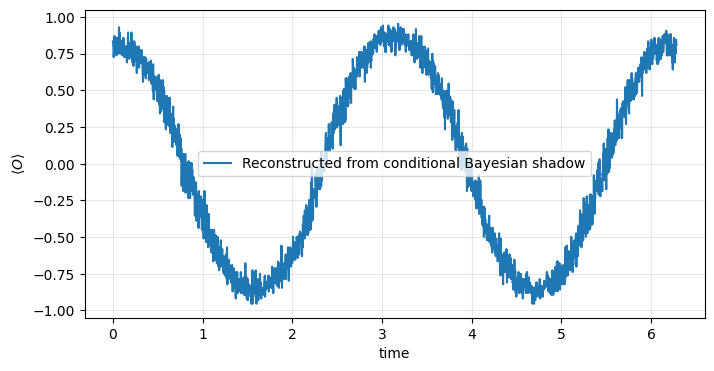

In [16]:
plt.figure(figsize=(8,4))
plt.plot(times, estimation_list, label="Reconstructed from conditional Bayesian shadow")
plt.xlabel("time")
plt.ylabel(r"$\langle O \rangle$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [6]:
config = StrategyOptimizationConfig(
    total_shots=10000,
    qubit_num=qubit_num,
    strategies=[(10, 1000), (20, 500), (25, 400), (50, 200), (100, 100), (200, 50),
                (500, 20), (1000, 10)],
    error_metric="rmse",
)

strategy_df = optimize_fixed_budget_strategy(result, tlist, operator, config)
fig, ax = plot_fixed_budget_strategy_errors(strategy_df)
plt.show()

Fixed-budget strategy sweep:   0%|          | 0/8 [00:00<?, ?it/s]

Reconstructing dynamics:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 